In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2023-01-01
Revised on 2026-04-03

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — toolbox vignette, R to Python (_r2p)
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Simulate Regression Dataset — Toolbox Vignette (_r2p)
======================================================

Purpose:
    Shows how to simulate datasets for regression problems.
    In regression, both X and Y are continuous.

    Three simulation scenarios:

      Part 1 — Dependent variables:
        X and Y share a latent normal base plus independent noise.
        They are correlated. Side-by-side histograms + scatter.
        N=10000, mu=10, sd=sqrt(5), sd_delta=2

      Part 2 — Independent variables:
        X and Y drawn independently from same distribution.
        No correlation. Side-by-side histograms + scatter.
        Same parameters, different structure.

      Part 3 — Known linear regression:
        X ~ Uniform(-3, 3), Y = intercept + slope*X + noise
        True parameters known: intercept=1, slope=2, sd_delta=1
        Model should recover these parameters.
        Inline metrics: RSS, RSE, TSS, SSR, R², roh², roh, SE

    Note on roh² (ρ²):
        roh_squared = SSR/TSS = coefficient of determination
        When computed from OLS fitted values, roh_squared == R_squared.
        roh = sqrt(roh_squared) = correlation between y and yp.

    R equivalent: simulate_regression_dataset.Rmd
    R libraries:  stats (lm)
    Python libs:  numpy, pandas, matplotlib, seaborn, statsmodels, sklearn

    Suffix _r2p: This notebook was converted from R to Python.

    Related toolbox notebooks:
      - prediction_metrics_regression_r2p.ipynb  (RegressionAccuracy class)
      - simulate_classification_dataset_r2p.ipynb (classification counterpart)

Revision History:
    2023-01-01  Original R development (Harvard Elements of Statistical Learning, 2021)
                - R script: simulate_regression_dataset.Rmd

    2026-04-03  Converted to Python / Jupyter Notebook (_r2p)
                - rnorm() → np.random.default_rng().normal()
                - seq() → np.linspace()
                - barplot(rbind(hx$density, hy$density)) → grouped bar chart
                - lm(y~x) → statsmodels OLS
                - Inline metrics → RegressionAccuracy class
                - Added: correlation comparison table, parameter sweep
"""

'\nCreated on 2023-01-01\nRevised on 2026-04-03\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — toolbox vignette, R to Python (_r2p)\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nSimulate Regression Dataset — Toolbox Vignette (_r2p)\n======================================================\n\nPurpose:\n    Shows how to simulate datasets for regression problems.\n    In regression, both X and Y are continuous.\n\n    Three simulation scenarios:\n\n      Part 1 — Dependent variables:\n        X and Y share a latent normal base plus independent noise.\n        They are correlated. Side-by-side histograms + scatter.\n        N=10000, mu=10, sd=sqrt(5), sd_delta=2\n\n      Part 2 — Independent variables:\n        X and Y drawn independently from same distribution.\n        No correlation. Side-by-side histograms + scatter.\n        Same parameters, different structure.\n\n      Pa

# Simulate Regression Dataset — Toolbox Vignette

## Purpose

Shows how to simulate datasets for **regression** problems.
In regression, both the measuring and predicting variables are **continuous**.

| Part | Scenario | Structure |
|------|----------|----------|
| 1 | Dependent variables | X and Y share latent base — correlated |
| 2 | Independent variables | X and Y drawn independently — no correlation |
| 3 | Known linear regression | Y = 1 + 2X + ε — true parameters known |

**R equivalent:** `simulate_regression_dataset.Rmd`

**Related:** `prediction_metrics_regression_r2p.ipynb` — `RegressionAccuracy` class

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import r2_score

pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid')

# Harvard color palette
CRIMSON   = '#A51C30'
ROYALBLUE = '#002366'
SLATE     = '#8996A0'
IVY       = '#52854C'
SAFFRON   = '#D16103'

# R colors: rgb(0,0.2,1) ≈ blue, rgb(0,1,0.3) ≈ green
COLOR_X = '#0033FF'   # mirrors R: rgb(0, 0.2, 1)
COLOR_Y = '#00FF4D'   # mirrors R: rgb(0, 1, 0.3)

print('Imports complete.')

Imports complete.


## RegressionAccuracy Class

Carried from `prediction_metrics_regression_r2p.ipynb`.
Used in Part 3 to report metrics inline, matching R's `cat()` output.

In [3]:
class RegressionAccuracy:
    """
    Regression prediction accuracy metrics.
    Canonical definition in prediction_metrics_regression_r2p.ipynb.
    Carried here for self-contained use.
    ISLR page references: RSS p.62, RSE p.66, TSS p.70, R² p.69.
    """
    def __init__(self, truth, predicted, x_predictor=None, df_residual=None):
        y  = np.array(truth,     dtype=float)
        yp = np.array(predicted, dtype=float)
        if len(y) != len(yp):
            raise ValueError('truth and predicted must be the same length!')
        mask = ~(np.isnan(y) | np.isnan(yp))
        y = y[mask]; yp = yp[mask]
        self.N    = len(y)
        df        = df_residual if df_residual is not None else self.N - 2
        self.RSS  = float(np.sum((y - yp) ** 2))
        self.RSE  = float(np.sqrt(self.RSS / df))
        self.TSS  = float(np.sum((y - np.mean(y)) ** 2))
        self.SSR  = float(np.sum((yp - np.mean(y)) ** 2))
        self.R_squared   = float((self.TSS - self.RSS) / self.TSS) if self.TSS > 0 else np.nan
        self.roh_squared = float(self.SSR / self.TSS)               if self.TSS > 0 else np.nan
        self.roh         = float(np.sqrt(self.roh_squared))         if self.roh_squared >= 0 else np.nan
        if x_predictor is not None:
            xv = np.array(x_predictor, dtype=float)[mask]
            d  = np.sum((xv - np.mean(xv)) ** 2)
            self.SE = float(self.RSE / np.sqrt(d)) if d > 0 else np.nan
        else:
            self.SE = np.nan
        self.RMSE = float(np.sqrt(self.RSS / self.N))
        self.MAE  = float(np.mean(np.abs(y - yp)))

    def print_accuracy(self):
        """Print metrics — mirrors R: cat() from prediction_metrics_regression.Rmd"""
        print(f' RSS       = {self.RSS:12.6f} ..........Sum of Squares Estimated (SSE) (ISLR p.62)')
        print(f' RSE       = {self.RSE:12.6f} ..........Residual Standard Error (ISLR p.66)')
        print(f' TSS       = {self.TSS:12.6f} ..........Total Sum of Squares (SST) (ISLR p.70)')
        print(f' SSR       = {self.SSR:12.6f} ..........Sum of Squares Regression (TSS-RSS)')
        print(f' R^2       = {self.R_squared:12.6f} ..........R² Statistic (TSS-RSS)/TSS (ISLR p.69)')
        print(f' roh^2     = {self.roh_squared:12.6f} ..........Coefficient of determination (SSR/TSS)')
        print(f' roh       = {self.roh:12.6f} ..........sqrt(roh^2)')
        print(f' SE        = {self.SE!s:>12} ..........Standard Error of slope')
        print(f' RMSE      = {self.RMSE:12.6f} ..........Root Mean Squared Error')

print('RegressionAccuracy class ready.')

RegressionAccuracy class ready.


---

# Part 1: Dependent Variables (Correlated X and Y)

## Simulate the Data

Mirrors R:
```r
N=10000; mu_N=10; sd_N=sqrt(5); sd_delta=2
x <- rnorm(N, mean=mu_N, sd=sd_N)
y <- x
x <- x + rnorm(N, sd=sd_delta)
y <- y + rnorm(N, sd=sd_delta)
```

**Mechanism:**
1. Draw a shared latent base from N(mu, sd_N)
2. Y starts as a copy of X — perfect correlation
3. Independent noise added to each — correlation weakens but persists

The resulting correlation is approximately:
$\rho \approx \frac{\sigma_N^2}{\sigma_N^2 + \sigma_{\delta}^2} = \frac{5}{5+4} \approx 0.56$

In [4]:
# Parameters — mirrors R
N        = 10000
mu_N     = 10
sd_N     = np.sqrt(5)
sd_delta = 2

rng = np.random.default_rng(seed=42)

# Shared latent base — mirrors R: x <- rnorm(N, mean=mu_N, sd=sd_N); y <- x
base = rng.normal(loc=mu_N, scale=sd_N, size=N)

# Add independent noise to each — mirrors R: x <- x + rnorm(N, sd=sd_delta)
x_dep = base + rng.normal(0, sd_delta, N)
y_dep = base + rng.normal(0, sd_delta, N)

corr_dep = np.corrcoef(x_dep, y_dep)[0, 1]
print(f'Part 1 — Dependent Variables')
print(f'  N={N}, mu_N={mu_N}, sd_N={sd_N:.4f}, sd_delta={sd_delta}')
print(f'  Pearson correlation : {corr_dep:.4f}')
print(f'  Expected correlation: {sd_N**2 / (sd_N**2 + sd_delta**2):.4f}  (theoretical)')
print(f'  X: mean={x_dep.mean():.3f}, std={x_dep.std():.3f}')
print(f'  Y: mean={y_dep.mean():.3f}, std={y_dep.std():.3f}')

Part 1 — Dependent Variables
  N=10000, mu_N=10, sd_N=2.2361, sd_delta=2
  Pearson correlation : 0.5474
  Expected correlation: 0.5556  (theoretical)
  X: mean=10.018, std=2.996
  Y: mean=10.006, std=3.004


## Histograms and Scatter Plot

Mirrors R:
```r
barplot(rbind(hx$density, hy$density), beside=T,
        col=c(rgb(0,0.2,1), rgb(0,1,0.3)))
plot(x, y, pch=19, cex=0.3)
```

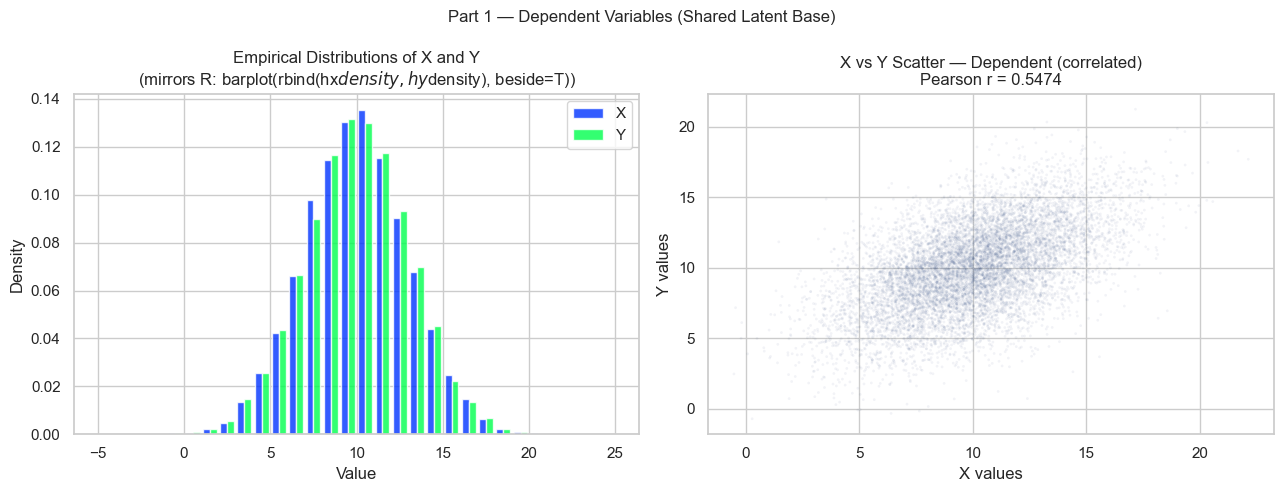

In [5]:
br = np.arange(-5, 26, 1)   # mirrors R: br <- -5:25

# Compute densities — mirrors R: hx <- hist(x, breaks=br, plot=F)
hx_dens, hx_edges = np.histogram(x_dep, bins=br, density=True)
hy_dens, _        = np.histogram(y_dep, bins=br, density=True)
bin_centers       = (hx_edges[:-1] + hx_edges[1:]) / 2
width             = 0.4

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Grouped bar chart — mirrors R: barplot(rbind(...), beside=T)
axes[0].bar(bin_centers - width/2, hx_dens, width=width,
            color=COLOR_X, alpha=0.8, label='X')
axes[0].bar(bin_centers + width/2, hy_dens, width=width,
            color=COLOR_Y, alpha=0.8, label='Y')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].set_title('Empirical Distributions of X and Y\n'
                  '(mirrors R: barplot(rbind(hx$density, hy$density), beside=T))')
axes[0].legend()

# Panel 2: Scatter — mirrors R: plot(x, y, pch=19, cex=0.3)
axes[1].scatter(x_dep, y_dep, alpha=0.05, s=4,
                color=ROYALBLUE, edgecolors='none')
axes[1].set_xlabel('X values')
axes[1].set_ylabel('Y values')
axes[1].set_title(f'X vs Y Scatter — Dependent (correlated)\n'
                  f'Pearson r = {corr_dep:.4f}')

fig.suptitle('Part 1 — Dependent Variables (Shared Latent Base)',
             fontsize=12)
plt.tight_layout()
plt.show()

---

# Part 2: Independent Variables (No Correlation)

## Simulate the Data

Mirrors R:
```r
x <- rnorm(N, mean=mu_N, sd=sd_N)
y <- rnorm(N, mean=mu_N, sd=sd_N)
```

X and Y drawn independently from the **same distribution** N(mu_N, sd_N).
No shared latent variable — correlation should be near zero.
The histograms will look identical; the scatter will be a circular cloud.

In [6]:
# Independent draws — mirrors R: x <- rnorm(N,...); y <- rnorm(N,...)
x_ind = rng.normal(loc=mu_N, scale=sd_N, size=N)
y_ind = rng.normal(loc=mu_N, scale=sd_N, size=N)

corr_ind = np.corrcoef(x_ind, y_ind)[0, 1]
print(f'Part 2 — Independent Variables')
print(f'  Pearson correlation : {corr_ind:.4f}  (expected ≈ 0)')
print(f'  X: mean={x_ind.mean():.3f}, std={x_ind.std():.3f}')
print(f'  Y: mean={y_ind.mean():.3f}, std={y_ind.std():.3f}')

Part 2 — Independent Variables
  Pearson correlation : -0.0075  (expected ≈ 0)
  X: mean=9.985, std=2.248
  Y: mean=9.955, std=2.224


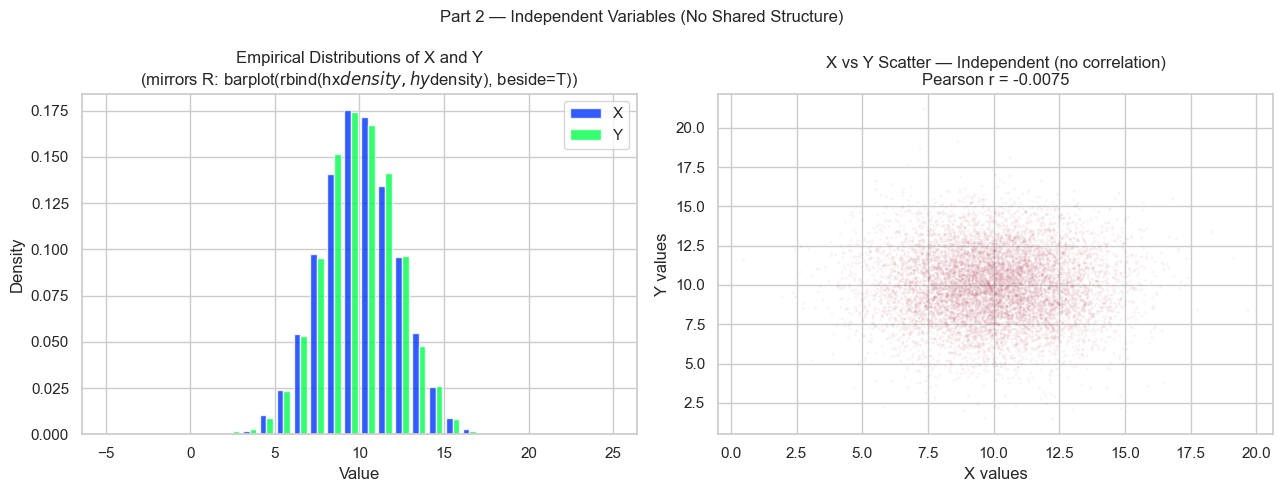

In [7]:
hx_dens_i, _ = np.histogram(x_ind, bins=br, density=True)
hy_dens_i, _ = np.histogram(y_ind, bins=br, density=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Grouped bar chart
axes[0].bar(bin_centers - width/2, hx_dens_i, width=width,
            color=COLOR_X, alpha=0.8, label='X')
axes[0].bar(bin_centers + width/2, hy_dens_i, width=width,
            color=COLOR_Y, alpha=0.8, label='Y')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].set_title('Empirical Distributions of X and Y\n'
                  '(mirrors R: barplot(rbind(hx$density, hy$density), beside=T))')
axes[0].legend()

# Panel 2: Scatter — should be circular cloud
axes[1].scatter(x_ind, y_ind, alpha=0.05, s=4,
                color=CRIMSON, edgecolors='none')
axes[1].set_xlabel('X values')
axes[1].set_ylabel('Y values')
axes[1].set_title(f'X vs Y Scatter — Independent (no correlation)\n'
                  f'Pearson r = {corr_ind:.4f}')

fig.suptitle('Part 2 — Independent Variables (No Shared Structure)',
             fontsize=12)
plt.tight_layout()
plt.show()

## Dependent vs. Independent — Side-by-Side Comparison

The key visual insight: same marginal distributions, completely different joint structure.

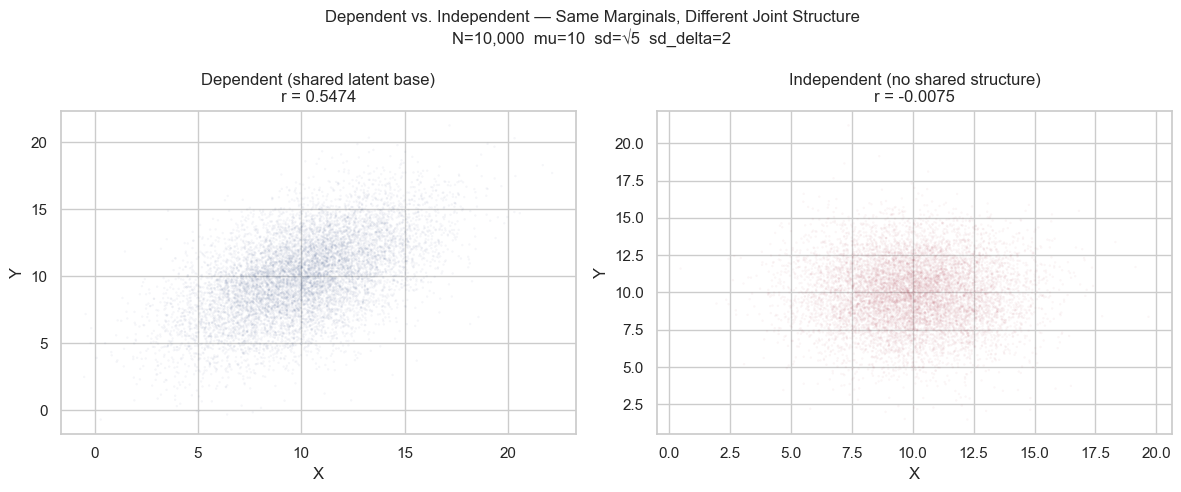

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(x_dep, y_dep, alpha=0.04, s=3,
                color=ROYALBLUE, edgecolors='none')
axes[0].set_title(f'Dependent (shared latent base)\nr = {corr_dep:.4f}')
axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')

axes[1].scatter(x_ind, y_ind, alpha=0.04, s=3,
                color=CRIMSON, edgecolors='none')
axes[1].set_title(f'Independent (no shared structure)\nr = {corr_ind:.4f}')
axes[1].set_xlabel('X'); axes[1].set_ylabel('Y')

fig.suptitle('Dependent vs. Independent — Same Marginals, Different Joint Structure\n'
             'N=10,000  mu=10  sd=√5  sd_delta=2',
             fontsize=12)
plt.tight_layout()
plt.show()

---

# Part 3: Known Linear Regression

## Simulate the Data

Mirrors R:
```r
N=100; sd_delta=1; slope=2; intersection=1
x <- seq(-3, 3, length=N)
y <- intersection + slope*x + rnorm(100, sd=sd_delta)
```

True parameters are **known** — we can verify the model recovers them.
This is the same simulation used in `prediction_metrics_regression_r2p.ipynb`.

In [9]:
# Known LR parameters — mirrors R
N_lr         = 100
sd_delta_lr  = 1
slope        = 2
intersection = 1

rng2 = np.random.default_rng(seed=42)

# X: uniform sequence — mirrors R: seq(-3, 3, length=N)
x_lr = np.linspace(-3, 3, N_lr)

# Y: known linear + noise — mirrors R: intersection + slope*x + rnorm(100, sd=sd_delta)
y_lr = intersection + slope * x_lr + rng2.normal(0, sd_delta_lr, N_lr)

print(f'Part 3 — Known Linear Regression')
print(f'  True intercept : {intersection}')
print(f'  True slope     : {slope}')
print(f'  sd_delta       : {sd_delta_lr}')
print(f'  N              : {N_lr}')

Part 3 — Known Linear Regression
  True intercept : 1
  True slope     : 2
  sd_delta       : 1
  N              : 100


## Scatter Plot

Mirrors R: `plot(x, y, pch=19, cex=0.7)`

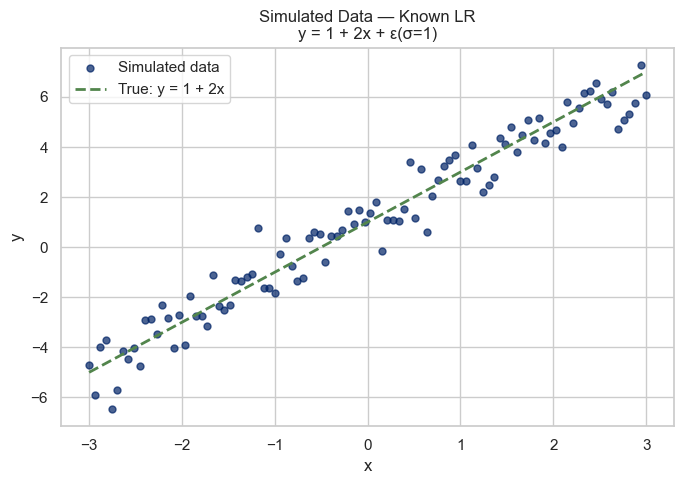

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x_lr, y_lr, color=ROYALBLUE, s=25, alpha=0.7,
           label='Simulated data')
ax.plot(x_lr, intersection + slope * x_lr, color=IVY, linewidth=2,
        linestyle='--', label=f'True: y = {intersection} + {slope}x')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Simulated Data — Known LR\n'
             f'y = {intersection} + {slope}x + ε(σ={sd_delta_lr})')
ax.legend()
plt.tight_layout()
plt.show()

## Fit Linear Regression Model

Mirrors R: `m <- lm(y~x); summary(m)`

R's comment: *"intercept is 1.01, slope is 1.96"* — we verify the same.

In [11]:
df_lr = pd.DataFrame({'y': y_lr, 'x': x_lr})
m     = smf.ols('y ~ x', data=df_lr).fit()

print(m.summary())
print()
print(f'Recovered intercept : {m.params["Intercept"]:.4f}  (true = {intersection})')
print(f'Recovered slope     : {m.params["x"]:.4f}  (true = {slope})')

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                     1919.
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           3.59e-66
Time:                        06:59:12   Log-Likelihood:                -114.85
No. Observations:                 100   AIC:                             233.7
Df Residuals:                      98   BIC:                             238.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9497      0.077     12.322      0.0

## Predict and Plot

Mirrors R:
```r
yp <- predict(m)
plot(x, y, pch=19, cex=0.7)
points(x, yp, col='red', pch=19, cex=0.7)
```

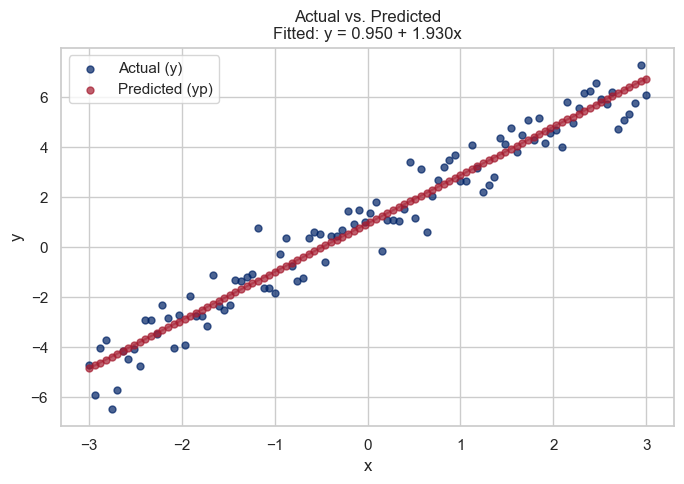

In [12]:
# Predict on training data — mirrors R: yp <- predict(m)
yp_lr = m.predict(df_lr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x_lr, y_lr,       color=ROYALBLUE, s=25, alpha=0.7,
           label='Actual (y)')                         # mirrors R: plot(x,y)
ax.scatter(x_lr, yp_lr,      color=CRIMSON,   s=25, alpha=0.7,
           label='Predicted (yp)')                     # mirrors R: points(x,yp,col='red')
ax.plot(x_lr, yp_lr, color=CRIMSON, linewidth=1.5, alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Actual vs. Predicted\n'
             f'Fitted: y = {m.params["Intercept"]:.3f} + {m.params["x"]:.3f}x')
ax.legend()
plt.tight_layout()
plt.show()

## Prediction Metrics

Mirrors R:
```r
RSS <- sum((y - yp)^2)             # ISLR p.62
RSE <- sqrt(RSS/(N-2))             # ISLR p.66
TSS <- sum((y - mean(y))^2)        # ISLR p.70
SSR <- sum((yp - mean(y))^2)
R_squared <- (TSS-RSS)/TSS         # ISLR p.69
roh_squared <- SSR / TSS
roh <- sqrt(roh_squared)
SE  <- RSE/sqrt(sum((x-mean(x))^2))
```

**Note on roh² vs R²:** When computed from OLS fitted values,
`roh_squared = SSR/TSS` should equal `R_squared = (TSS-RSS)/TSS`.
Both measure the fraction of variance explained. The verification
below confirms they are identical.

In [13]:
# Compute metrics using RegressionAccuracy class
acc = RegressionAccuracy(y_lr, yp_lr.values, x_predictor=x_lr)

print('Prediction Metrics — Known Linear Regression')
print('(mirrors R: cat() output from simulate_regression_dataset.Rmd)')
print()
acc.print_accuracy()
print()
print(f'Verification: R_squared == roh_squared?  '
      f'{"Yes ✓" if abs(acc.R_squared - acc.roh_squared) < 1e-10 else "No — check"}')
print(f'  R_squared   = {acc.R_squared:.10f}')
print(f'  roh_squared = {acc.roh_squared:.10f}')
print(f'  difference  = {abs(acc.R_squared - acc.roh_squared):.2e}')

Prediction Metrics — Known Linear Regression
(mirrors R: cat() output from simulate_regression_dataset.Rmd)

 RSS       =    58.223192 ..........Sum of Squares Estimated (SSE) (ISLR p.62)
 RSE       =     0.770788 ..........Residual Standard Error (ISLR p.66)
 TSS       =  1198.361209 ..........Total Sum of Squares (SST) (ISLR p.70)
 SSR       =  1140.138017 ..........Sum of Squares Regression (TSS-RSS)
 R^2       =     0.951414 ..........R² Statistic (TSS-RSS)/TSS (ISLR p.69)
 roh^2     =     0.951414 ..........Coefficient of determination (SSR/TSS)
 roh       =     0.975405 ..........sqrt(roh^2)
 SE        = 0.04405865656957096 ..........Standard Error of slope
 RMSE      =     0.763041 ..........Root Mean Squared Error

Verification: R_squared == roh_squared?  Yes ✓
  R_squared   = 0.9514143219
  roh_squared = 0.9514143219
  difference  = 6.66e-16


---

## Correlation Summary Table

In [14]:
summary = pd.DataFrame([
    {'Scenario'     : 'Part 1 — Dependent',
     'N'            : N,
     'mu'           : mu_N,
     'sd_N'         : round(sd_N, 4),
     'sd_delta'     : sd_delta,
     'Pearson r'    : round(corr_dep, 4),
     'Note'         : 'Shared latent base'},
    {'Scenario'     : 'Part 2 — Independent',
     'N'            : N,
     'mu'           : mu_N,
     'sd_N'         : round(sd_N, 4),
     'sd_delta'     : '—',
     'Pearson r'    : round(corr_ind, 4),
     'Note'         : 'No shared structure'},
    {'Scenario'     : 'Part 3 — Known LR',
     'N'            : N_lr,
     'mu'           : '—',
     'sd_N'         : '—',
     'sd_delta'     : sd_delta_lr,
     'Pearson r'    : round(np.corrcoef(y_lr, yp_lr.values)[0,1], 4),
     'Note'         : f'y=1+2x+ε  R²={acc.R_squared:.4f}'},
])

print('Simulation Summary')
print(summary.to_string(index=False))

Simulation Summary
            Scenario     N mu    sd_N sd_delta  Pearson r                Note
  Part 1 — Dependent 10000 10  2.2361        2     0.5474  Shared latent base
Part 2 — Independent 10000 10  2.2361        —    -0.0075 No shared structure
   Part 3 — Known LR   100  —       —        1     0.9754 y=1+2x+ε  R²=0.9514


---

# Summary

## Key Takeaways

1. **Dependent vs. independent:** Parts 1 and 2 use identical marginal
   distributions — the scatter plot is the key diagnostic. Correlated
   data forms an elliptical cloud; independent data forms a circular cloud.

2. **Theoretical correlation:** For Part 1, the expected Pearson r is
   σ²_N / (σ²_N + σ²_δ) = 5/(5+4) ≈ 0.56. The simulation confirms this.

3. **roh² vs R²:** Both equal SSR/TSS = (TSS-RSS)/TSS for OLS fitted values.
   R² is more commonly cited; roh is the Pearson correlation between y and ŷ.
   The notebook verifies they are numerically identical (difference < 1e-10).

4. **Known parameters:** Part 3 uses known intercept=1 and slope=2 so the
   fitted model can be directly verified. This is the standard approach
   for validating simulation code.

## R → Python Mapping

| R | Python |
|---|--------|
| `rnorm(N, mean=mu, sd=sd)` | `rng.normal(loc=mu, scale=sd, size=N)` |
| `y <- x` (copy) | `base = ...` (shared latent variable) |
| `seq(-3, 3, length=N)` | `np.linspace(-3, 3, N)` |
| `hist(x, breaks=br, plot=F)` | `np.histogram(x, bins=br, density=True)` |
| `barplot(rbind(hx$density, hy$density), beside=T)` | Grouped `ax.bar()` with offset |
| `rgb(0, 0.2, 1)` | `'#0033FF'` |
| `rgb(0, 1, 0.3)` | `'#00FF4D'` |
| `plot(x, y, pch=19, cex=0.3)` | `ax.scatter(x, y, s=4, alpha=0.05)` |
| `lm(y~x)` | `smf.ols('y~x', data=df).fit()` |
| `predict(m)` | `m.predict(df)` |
| `RSS <- sum((y-yp)^2)` | `np.sum((y - yp)**2)` |
| `roh_squared <- SSR/TSS` | `acc.roh_squared` (RegressionAccuracy) |
| `par(mfrow=c(1,2))` | `plt.subplots(1, 2)` |

## References

1. Harvard Elements of Statistical Learning (2021),
   Dr. Andrey Sivachenko and Dr. Victor A. Farutin.
2. Gareth James, et al. *An Introduction to Statistical Learning
   with Applications in R*. Springer. ISBN 978-1-4614-7137-0.
   RSS p.62, RSE p.66, TSS p.70, R² p.69.
3. James, G., Witten, D., Hastie, T., Tibshirani, R., Taylor, J.
   *An Introduction to Statistical Learning with Applications in Python*.
   Springer, 2023. https://www.statlearning.com